In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict 
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [8]:
load_dotenv()

True

In [4]:
class state(TypedDict):
    topic:str 
    joke:str
    explanation:str
    

In [9]:
model =ChatOpenAI()

In [12]:
def joke_generator(state:state)->state:
    prompt=f"Generate a joke about {state['topic']}"
    joke=model.invoke(prompt).content
    return {"joke":joke}  

def explanation_generator(state:state)->state:
    promopt=f"Explain the joke: {state['joke']}"
    explanation=model.invoke(promopt).content
    return {"explanation":explanation}

In [13]:
graph=StateGraph(state)
graph.add_node("joke",joke_generator)
graph.add_node("explanation",explanation_generator)
graph.add_edge(START,"joke")
graph.add_edge("joke","explanation")
graph.add_edge("explanation",END)
checkpoint=InMemorySaver()
response=graph.compile(checkpointer=checkpoint)


In [15]:
thread_id=1
config={"configurable":{"thread_id":thread_id}}
answers=response.invoke({"topic":"programming"},config=config)
print(answers)


{'topic': 'programming', 'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!', 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a bug refers to an error or flaw in a software program. By saying that programmers prefer dark mode because the light attracts bugs, it is implying that bugs in the program are more noticeable in light mode, so programmers prefer to work in dark mode to avoid being distracted by them.'}


In [17]:
response.get_state(config=config)


StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!', 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a bug refers to an error or flaw in a software program. By saying that programmers prefer dark mode because the light attracts bugs, it is implying that bugs in the program are more noticeable in light mode, so programmers prefer to work in dark mode to avoid being distracted by them.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d399-27c9-6eb9-8006-62fcf360f612'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-21T04:21:30.526670+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d399-1c0c-658f-8005-c350feb80016'}}, tasks=(), interrupts=())

In [20]:
list(response.get_state_history(config))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!', 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a bug refers to an error or flaw in a software program. By saying that programmers prefer dark mode because the light attracts bugs, it is implying that bugs in the program are more noticeable in light mode, so programmers prefer to work in dark mode to avoid being distracted by them.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d399-27c9-6eb9-8006-62fcf360f612'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-21T04:21:30.526670+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d399-1c0c-658f-8005-c350feb80016'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode? \nBecaus

In [24]:
thread_id=2
config2={"configurable":{"thread_id":thread_id}}
answers=response.invoke({"topic":"sleeping"},config=config2)
print(answers)


{'topic': 'sleeping', 'joke': 'Why did the pillow go to school? Because it wanted to take a nap-tual exam!', 'explanation': 'This joke is a play on words. The term "nap-tual exam" sounds like "actual exam". The joke is that the pillow went to school to take an exam, but instead of a regular exam, it wanted to take a "nap-tual exam" because pillows are typically associated with napping. It\'s a lighthearted and silly joke based on wordplay.'}


In [25]:
response.get_state(config2)

StateSnapshot(values={'topic': 'sleeping', 'joke': 'Why did the pillow go to school? Because it wanted to take a nap-tual exam!', 'explanation': 'This joke is a play on words. The term "nap-tual exam" sounds like "actual exam". The joke is that the pillow went to school to take an exam, but instead of a regular exam, it wanted to take a "nap-tual exam" because pillows are typically associated with napping. It\'s a lighthearted and silly joke based on wordplay.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13d3a0-e032-6c67-800e-c104b73ef2da'}}, metadata={'source': 'loop', 'step': 14, 'parents': {}}, created_at='2026-04-21T04:24:57.768217+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13d3a0-d1d7-6635-800d-bca3f664655f'}}, tasks=(), interrupts=())

In [26]:
list(response.get_state_history(config2))

[StateSnapshot(values={'topic': 'sleeping', 'joke': 'Why did the pillow go to school? Because it wanted to take a nap-tual exam!', 'explanation': 'This joke is a play on words. The term "nap-tual exam" sounds like "actual exam". The joke is that the pillow went to school to take an exam, but instead of a regular exam, it wanted to take a "nap-tual exam" because pillows are typically associated with napping. It\'s a lighthearted and silly joke based on wordplay.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13d3a0-e032-6c67-800e-c104b73ef2da'}}, metadata={'source': 'loop', 'step': 14, 'parents': {}}, created_at='2026-04-21T04:24:57.768217+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13d3a0-d1d7-6635-800d-bca3f664655f'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'sleeping', 'joke': 'Why did the pillow go to school? Because it wanted to take a nap-tual exam!', 'explanat

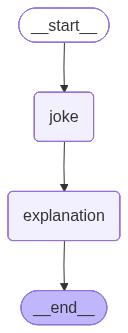

In [27]:
response